# ![Machine Learning Lab](banner.jpg)

# Laboratorio 8 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab8.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Construir y entrenar una Red Neuronal Convolucional (CNN) para clasificación de imágenes médicas.
2. Aplicar técnicas de preprocesamiento y aumentación de datos a imágenes.
3. Evaluar y comparar el desempeño del modelo con y sin data augmentation.

---

En esta ocasión trabajaremos con el dataset **Brain Tumor MRI Images**, que contiene imágenes de resonancia magnética cerebral clasificadas en 4 categorías: **Glioma**, **Meningioma**, **Pituitary** y **Healthy**.

Dataset: [Brain Tumor MRI Images](https://www.kaggle.com/datasets/miadul/brain-tumor-mri-dataset/data)

---

## Instrucciones

### 1. Carga y exploración de datos (10%)

1. Descarga el dataset utilizando `kagglehub`:
   ```python
   import kagglehub
   path = kagglehub.dataset_download('miadul/brain-tumor-mri-dataset')
   ```
2. Explora la estructura de carpetas del dataset y cuenta el número de imágenes por clase.
3. Visualiza al menos 3 imágenes de ejemplo de cada clase en una cuadrícula.
4. Muestra la distribución de clases en un gráfico de barras. ¿El dataset está balanceado?

---

### 2. Preprocesamiento de datos (20%)

1. Redimensiona todas las imágenes a un tamaño uniforme (por ejemplo, 150×150 píxeles).
2. Normaliza los valores de los píxeles al rango [0, 1].
3. Divide el dataset en conjuntos de entrenamiento (70%), validación (15%) y prueba (15%). Utiliza `seed = 42`.
4. Crea los datasets de TensorFlow/Keras utilizando `image_dataset_from_directory`.

---

### 3. Modelo CNN base (30%)

1. Construye una CNN con al menos 3 bloques convolucionales (Conv2D + MaxPooling2D).
2. Agrega capas Dense para la clasificación final.
3. Muestra el resumen del modelo (`model.summary()`) e indica el número total de parámetros.
4. Compila el modelo con el optimizador y función de pérdida adecuados para clasificación multiclase.
5. Entrena el modelo.
6. Grafica las curvas de pérdida y precisión (entrenamiento vs validación).

---

### 4. Data Augmentation (30%)

1. Define una estrategia de aumentación de datos que incluya al menos 3 transformaciones (rotación, volteo, zoom, etc.).
2. Visualiza el efecto de la aumentación sobre algunas imágenes de ejemplo.
3. Construye un nuevo modelo CNN que integre las capas de aumentación.
4. Entrena el modelo.
5. Grafica las curvas de aprendizaje del modelo con aumentación.
6. Compara la precisión del modelo con y sin aumentación en el conjunto de prueba.

---

### 5. Análisis de resultados (10%)

1. Genera la matriz de confusión para ambos modelos (con y sin aumentación).
2. ¿Cuáles tipos de tumor son más difíciles de clasificar?
3. Reporta la precisión (accuracy), precisión por clase y recall por clase para el mejor modelo.

---


# Entrega

### 1. Carga y exploración de datos (10%)

1. Descarga el dataset utilizando `kagglehub`:
   ```python
   import kagglehub
   path = kagglehub.dataset_download('miadul/brain-tumor-mri-dataset')
   ```
2. Explora la estructura de carpetas del dataset y cuenta el número de imágenes por clase.
3. Visualiza al menos 3 imágenes de ejemplo de cada clase en una cuadrícula.
4. Muestra la distribución de clases en un gráfico de barras. ¿El dataset está balanceado?


In [1]:
import kagglehub
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import shutil
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np

warnings.filterwarnings("ignore")

/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# descargar el dataset de kaggle
dataset_path = kagglehub.dataset_download('miadul/brain-tumor-mri-dataset')
print(f'Dataset descargado en: {dataset_path}')

Dataset descargado en: /Users/estefanialaverdebecerra/.cache/kagglehub/datasets/miadul/brain-tumor-mri-dataset/versions/1


In [3]:
# explorar la estructura de las carpetas
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    folder_name = os.path.basename(root)
    num_files = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
    if num_files > 0:
        print(f'{indent}{folder_name}/ ({num_files} imágenes)')
    else:
        print(f'{indent}{folder_name}/')

1/
  brain_tumor_dataset/
    pituitary/ (1757 imágenes)
    healthy/ (2000 imágenes)
    glioma/ (1621 imágenes)
    meningioma/ (1645 imágenes)


Podemos observar que el dataset contiene 4 carpetas principales, cada una con un diferente tumor/estado de salud. Cada carpeta corresponde entonces a una clase diferente.

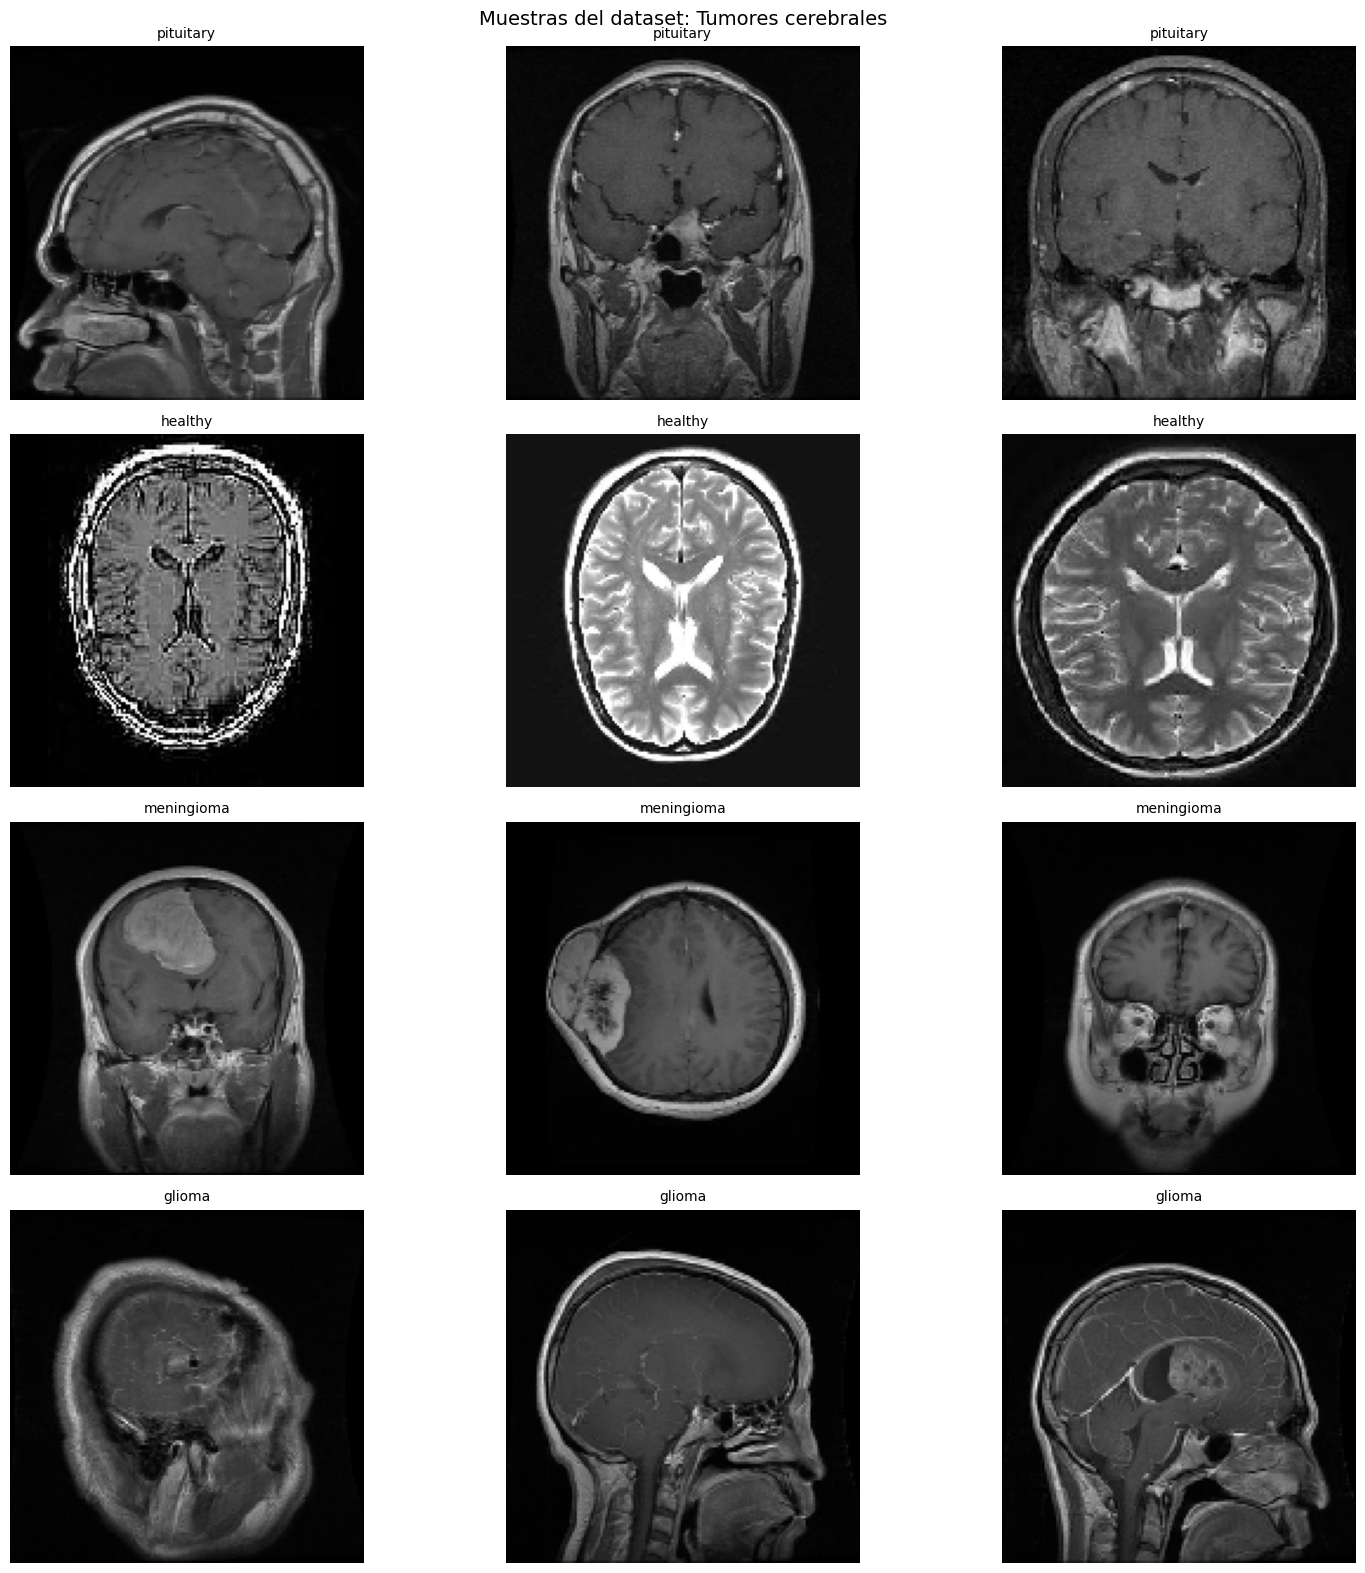

In [4]:
# visualizar imagenes de ejemplo, 3 por clase
fig, axes = plt.subplots(4, 3, figsize=(16, 16))

for row, class_name in enumerate(['pituitary', 'healthy', 'meningioma', 'glioma']):
    class_dir = Path(dataset_path) / 'brain_tumor_dataset' / class_name
    image_files = sorted(class_dir.glob('*'))[:3]
    for col, img_path in enumerate(image_files):
        img = tf.keras.utils.load_img(img_path, target_size=(150, 150))
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name, fontsize=10)
        axes[row, col].axis('off')

plt.suptitle('Muestras del dataset: Tumores cerebrales', fontsize=14)
plt.tight_layout()
plt.show()

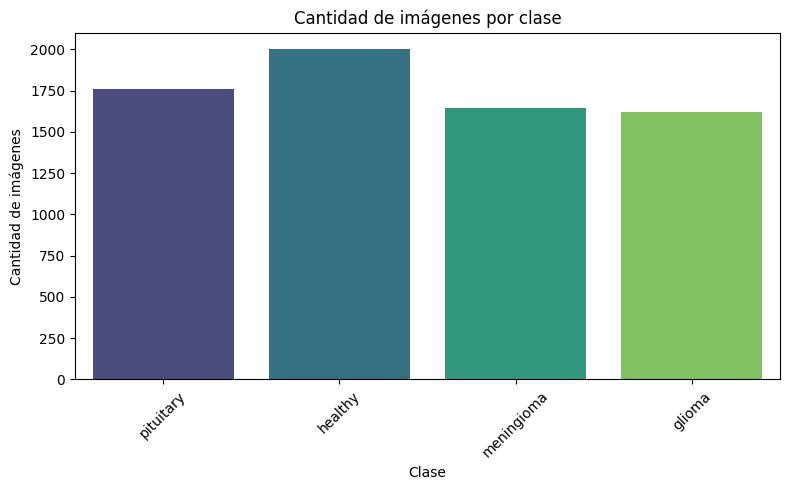

In [5]:
# mostrar la cantidad de imágenes por clase
class_counts = {}
for class_name in ['pituitary', 'healthy', 'meningioma', 'glioma']:
    class_dir = Path(dataset_path) / 'brain_tumor_dataset' / class_name
    class_counts[class_name] = len(list(class_dir.glob('*')))

plt.figure(figsize=(8, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
plt.title('Cantidad de imágenes por clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Con el grafico de barras podemos concluir que el dataset está balanceado, con una ligera predominancia de la clase "healthy".

### 2. Preprocesamiento de datos (20%)

1. Redimensiona todas las imágenes a un tamaño uniforme (por ejemplo, 150×150 píxeles).
2. Normaliza los valores de los píxeles al rango [0, 1].
3. Divide el dataset en conjuntos de entrenamiento (70%), validación (15%) y prueba (15%). Utiliza `seed = 42`.
4. Crea los datasets de TensorFlow/Keras utilizando `image_dataset_from_directory`.

In [ ]:
# redimensionar las imagenes a 150x150
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

full_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    Path(dataset_path) / 'brain_tumor_dataset', # directorio a las carpetas de clases
    labels='inferred', # las etiquetas se toman como los nombres de las carpetas
    label_mode='categorical', # categorical para clasificación multiclase, devuelve one-hot encoding
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED,
    shuffle=True # la mezcla se hace aquí para asegurar que la división tenga en cuenta todas las clases
)

# confirmar las etiquetas
class_names = full_dataset.class_names
print(f'Clases detectadas: {class_names}')

# normalización - se realiza en todo el dataset para que la división en train/val/test tenga datos ya normalizados
normalization_layer = tf.keras.layers.Rescaling(1./255)
normalized_dataset = full_dataset.map(lambda x, y: (normalization_layer(x), y))

# división en train test y val
num_batches = normalized_dataset.cardinality().numpy()

train_size = int(0.7 * num_batches)
val_size = int(0.15 * num_batches)

train_dataset = normalized_dataset.take(train_size)
remaining = normalized_dataset.skip(train_size)

val_dataset = remaining.take(val_size)
test_dataset = remaining.skip(val_size)

# optimización del rendimiento con cache y prefetch: cache guarda los datos en memoria después de la primera época y prefetch permite cargar los datos mientras el modelo está entrenando, reduciendo el tiempo de espera entre épocas
train_dataset = train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 7023 files belonging to 4 classes.
Clases detectadas: ['glioma', 'healthy', 'meningioma', 'pituitary']


### 3. Modelo CNN base (30%)

1. Construye una CNN con al menos 3 bloques convolucionales (Conv2D + MaxPooling2D).
2. Agrega capas Dense para la clasificación final.
3. Muestra el resumen del modelo (`model.summary()`) e indica el número total de parámetros.
4. Compila el modelo con el optimizador y función de pérdida adecuados para clasificación multiclase.
5. Entrena el modelo.
6. Grafica las curvas de pérdida y precisión (entrenamiento vs validación).


A continuación se define el modelo CNN, con 3 bloques convolucionales, cada uno con un kernel de tamaño 3x3 y función de activación ReLU, seguido de una capa de MaxPooling2D para reducir la dimensionalidad. Luego se agregan capas Dense para la clasificación final, con una capa de salida con activación softmax para obtener probabilidades de cada clase.

In [ ]:
NUM_CLASSES = len(class_names)

# modelo
cnn_model = tf.keras.Sequential([
    # capas convolucionales
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # clasificación
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# número total de parametros
total_params = cnn_model.count_params()
print(f'Total de parámetros: {total_params:,}')
print(f'Parámetros entrenables: {sum(p.numpy().size for p in cnn_model.trainable_weights):,}')

Total de parámetros: 4,828,868
Parámetros entrenables: 4,828,868


El modelo se compila con el optimizador Adam para actualización de los pesos, la función de pérdida `categorical_crossentropy` pues es la adecuada para clasificación multiclase, y se monitorea la métrica de precisión.

In [9]:
# compilación del modelo
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

A continuación se entrena el modelo en 15 épocas, utilizando el conjunto de validación para monitorear el desempeño del modelo durante el entrenamiento.

In [10]:
# entrenamiento del modelo
history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15
)

Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 25s 160ms/step - accuracy: 0.5840 - loss: 1.0033 - val_accuracy: 0.8333 - val_loss: 0.4396
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - accuracy: 0.8478 - loss: 0.3853 - val_accuracy: 0.9062 - val_loss: 0.2730
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 24s 156ms/step - accuracy: 0.9232 - loss: 0.2160 - val_accuracy: 0.9148 - val_loss: 0.2683
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.9338 - loss: 0.1617 - val_accuracy: 0.9214 - val_loss: 0.2222
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 25s 161ms/step - accuracy: 0.9757 - loss: 0.0749 - val_accuracy: 0.9044 - val_loss: 0.2388
Epoch 6/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 25s 159ms/step - accuracy: 0.9689 - loss: 0.0874 - val_accuracy: 0.9205 - val_loss: 0.2679
Epoch 7/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.9882 - loss: 0.0340 - val_accuracy: 0.9062 - val_loss: 0.3059
Epoch 8/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 25s 164ms/step - accuracy: 0.9949 - loss: 0

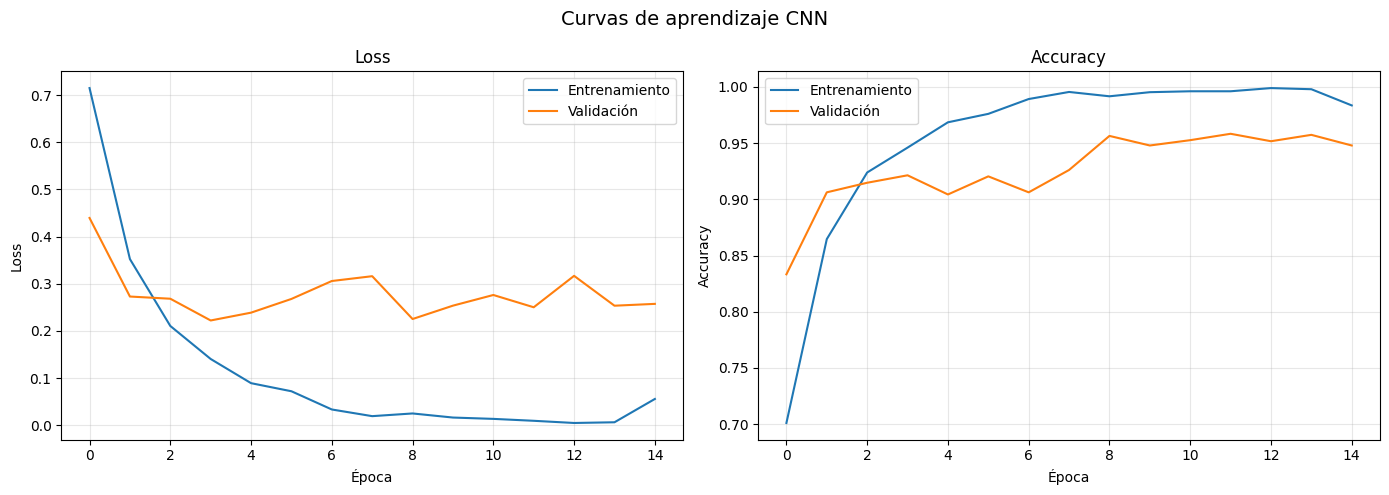

In [11]:
# curvas de aprendizaje
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Entrenamiento')
ax1.plot(history.history['val_loss'], label='Validación')
ax1.set_title('Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], label='Entrenamiento')
ax2.plot(history.history['val_accuracy'], label='Validación')
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje CNN', fontsize=14)
plt.tight_layout()
plt.show()

En las curvas de aprendizaje podemos observar como tanto la pérdida de entrenamiento como la de validación disminuyen a lo largo de las primeras épocas, y luego se estabilizan. El comportamiento no exhibe signos de sobreajuste, pues la pérdida de validación no aumenta mientras la de entrenamiento sigue disminuyendo, lo que sugiere que el modelo está generalizando bien a los datos de validación. 

Con respecto al accuracy, el modelo alcanza una precisión de alrededor de 90% en el conjunto de validación, lo que indica un buen desempeño para la tarea de clasificación presentada.

### 4. Data Augmentation (30%)

1. Define una estrategia de aumentación de datos que incluya al menos 3 transformaciones (rotación, volteo, zoom, etc.).
2. Visualiza el efecto de la aumentación sobre algunas imágenes de ejemplo.
3. Construye un nuevo modelo CNN que integre las capas de aumentación.
4. Entrena el modelo.
5. Grafica las curvas de aprendizaje del modelo con aumentación.
6. Compara la precisión del modelo con y sin aumentación en el conjunto de prueba.

Ahora se define una estrategia de aumentación de datos que incluye rotación aleatoria de hasta 15 grados, zoom aleatorio de hasta el 30% y volteo tanto horizontal como vertical aleatorio. Se puede visualizar el efecto sobre una imagen de ejemplo.

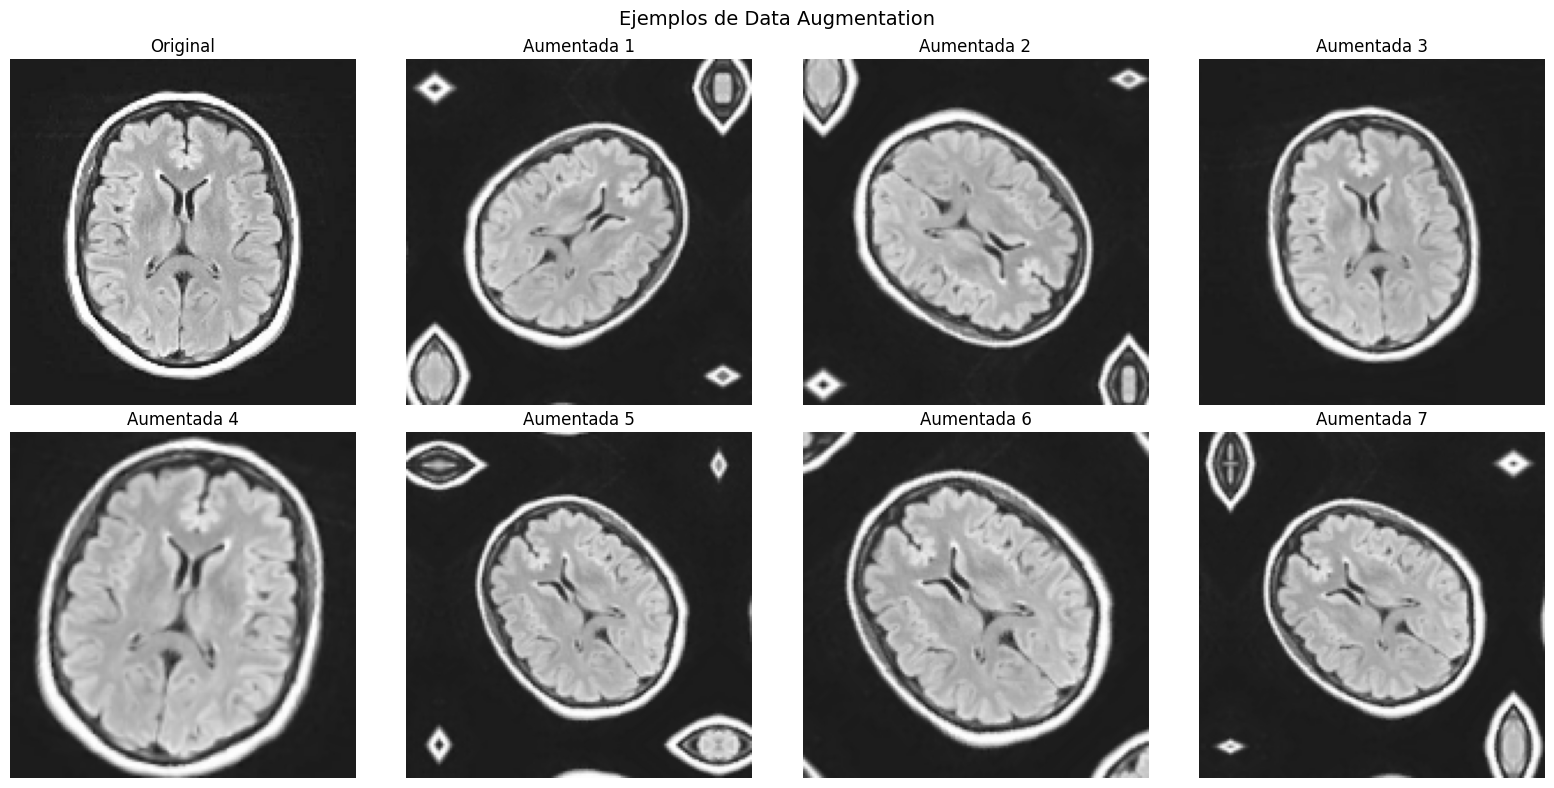

In [12]:
# aumentación de datos
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('vertical'),
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.3)
])

# visualizar el efecto
for images, _ in train_dataset.take(1):
    sample = images[0]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes[0, 0].imshow(sample.numpy())
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    for i, ax in enumerate(axes.flatten()[1:], 1):
        augmented = data_augmentation(tf.expand_dims(sample, 0))
        ax.imshow(augmented[0].numpy())
        ax.set_title(f'Aumentada {i}')
        ax.axis('off')
    plt.suptitle('Ejemplos de Data Augmentation', fontsize=14)
    plt.tight_layout()
    plt.show()
    break

Se incluye la estrategio de aumentación como parte del modelo CNN, lo que permite que las transformaciones se apliquen de manera aleatoria durante el entrenamiento, aumentando la diversidad de los datos y ayudando a prevenir el sobreajuste.

In [13]:
# nuevo modelo con data augmentation
aug_model = tf.keras.Sequential([
    # data augmentation
        tf.keras.layers.RandomFlip('vertical', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.15),
        tf.keras.layers.RandomZoom(0.3),

    # capas convolucionales
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # clasificación
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

aug_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
aug_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_3 (RandomFlip)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# entrenamiento del modelo con data augmentation
aug_history = aug_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15
)

Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 25s 161ms/step - accuracy: 0.4257 - loss: 1.2343 - val_accuracy: 0.4716 - val_loss: 1.1505
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 26s 169ms/step - accuracy: 0.6787 - loss: 0.8021 - val_accuracy: 0.6345 - val_loss: 0.8160
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 27s 174ms/step - accuracy: 0.7359 - loss: 0.6620 - val_accuracy: 0.7528 - val_loss: 0.6092
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 28s 180ms/step - accuracy: 0.7567 - loss: 0.6078 - val_accuracy: 0.6193 - val_loss: 0.8709
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 29s 189ms/step - accuracy: 0.7932 - loss: 0.5317 - val_accuracy: 0.6155 - val_loss: 0.9358
Epoch 6/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 31s 203ms/step - accuracy: 0.8047 - loss: 0.5145 - val_accuracy: 0.7822 - val_loss: 0.5676
Epoch 7/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 206ms/step - accuracy: 0.8278 - loss: 0.4437 - val_accuracy: 0.7102 - val_loss: 0.6886
Epoch 8/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 32s 207ms/step - accuracy: 0.8373 - loss: 0

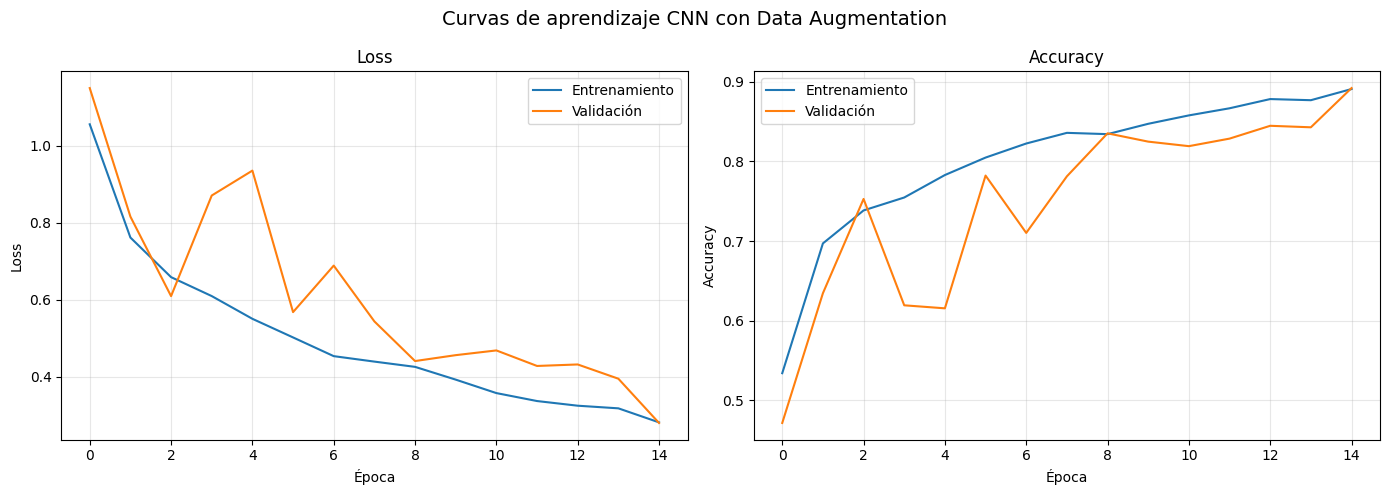

In [15]:
# curvas de aprendizaje
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(aug_history.history['loss'], label='Entrenamiento')
ax1.plot(aug_history.history['val_loss'], label='Validación')
ax1.set_title('Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(aug_history.history['accuracy'], label='Entrenamiento')
ax2.plot(aug_history.history['val_accuracy'], label='Validación')
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje CNN con Data Augmentation', fontsize=14)
plt.tight_layout()
plt.show()

Con estas curvas de aprendizaje del modelo con aumentación, se puede observar que el modelo sigue un comportamiento similar al del modelo sin aumentación, con algunos picos pronunciados en las primeras épocas, tanto en loss como en accuracy, lo que puede ser indicativo de la naturaleza aleatoria de las transformaciones aplicadas a los datos durante el entrenamiento. Sin embargo, a medida que avanza el entrenamiento, las curvas se estabilizan y muestran una tendencia general de mejora en la precisión y disminución en la pérdida.

In [16]:
# calcular la precisión en el conjunto de test
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(test_dataset)
test_loss_aug, test_acc_aug = aug_model.evaluate(test_dataset)
print(f'Precisión en el conjunto de test modelo sin Data Augmentation: {test_acc_cnn:.4f}')
print(f'Precisión en el conjunto de test modelo con Data Augmentation: {test_acc_aug:.4f}')

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9300 - loss: 0.3732
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.8628 - loss: 0.3435
Precisión en el conjunto de test modelo sin Data Augmentation: 0.9278
Precisión en el conjunto de test modelo con Data Augmentation: 0.8758


### 5. Análisis de resultados (10%)

1. Genera la matriz de confusión para ambos modelos (con y sin aumentación).
2. ¿Cuáles tipos de tumor son más difíciles de clasificar?
3. Reporta la precisión (accuracy), precisión por clase y recall por clase para el mejor modelo.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━

2026-04-09 19:19:09.830224: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


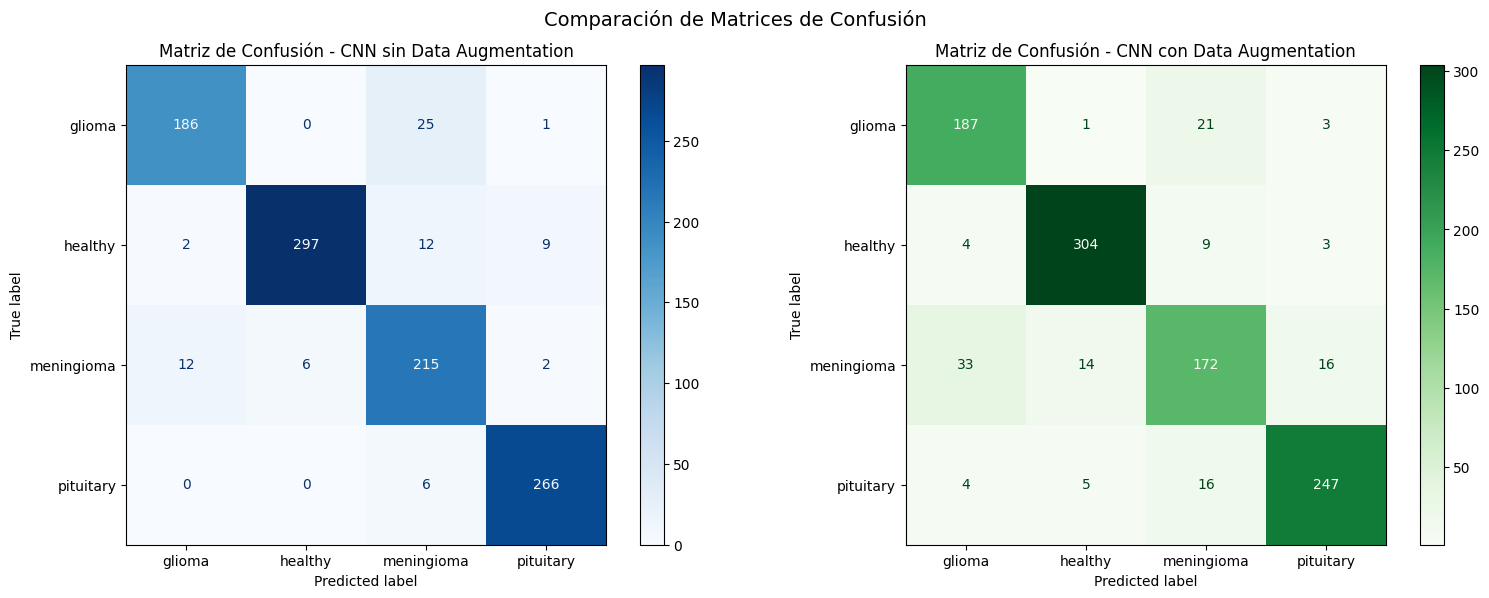

In [17]:
# matrices de confusión para ambos modelos
y_true = []
y_pred_cnn = []
y_pred_aug = []
for images, labels in test_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_cnn.extend(np.argmax(cnn_model.predict(images), axis=1))
    y_pred_aug.extend(np.argmax(aug_model.predict(images), axis=1))

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
cm_aug = confusion_matrix(y_true, y_pred_aug)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)
disp_aug = ConfusionMatrixDisplay(confusion_matrix=cm_aug, display_labels=class_names)

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
disp_cnn.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Matriz de Confusión - CNN sin Data Augmentation')
disp_aug.plot(ax=ax2, cmap='Greens', values_format='d')
ax2.set_title('Matriz de Confusión - CNN con Data Augmentation')
plt.suptitle('Comparación de Matrices de Confusión', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# reporte de clasificación modelo sin data augmentation
report_cnn = classification_report(y_true, y_pred_cnn, target_names=class_names)
print('Reporte de Clasificación - CNN sin Data Augmentation:\n')
print(report_cnn)

# reporte de clasificación modelo con data augmentation
report_aug = classification_report(y_true, y_pred_aug, target_names=class_names)
print('Reporte de Clasificación - CNN con Data Augmentation:\n')
print(report_aug)

Reporte de Clasificación - CNN sin Data Augmentation:

              precision    recall  f1-score   support

      glioma       0.93      0.88      0.90       212
     healthy       0.98      0.93      0.95       320
  meningioma       0.83      0.91      0.87       235
   pituitary       0.96      0.98      0.97       272

    accuracy                           0.93      1039
   macro avg       0.93      0.92      0.92      1039
weighted avg       0.93      0.93      0.93      1039

Reporte de Clasificación - CNN con Data Augmentation:

              precision    recall  f1-score   support

      glioma       0.82      0.88      0.85       212
     healthy       0.94      0.95      0.94       320
  meningioma       0.79      0.73      0.76       235
   pituitary       0.92      0.91      0.91       272

    accuracy                           0.88      1039
   macro avg       0.87      0.87      0.87      1039
weighted avg       0.88      0.88      0.88      1039



Los tipos de tumor más difíciles de clasificar teniendo en cuenta los resultados de la matriz de confusión y el reporte de clasificación son los del meningioma, los cuales suele confundir principalmente con el glioma. Concidencialmente, estas son las dos clases que tienen la menor cantidad de imágenes en el dataset (a pesar de que es un dataset bastante balanceado).
Podemos observar que el modelo con data augmentation tiene una precisión inferior al modelo sin data augmentation. Esto puede variar según el tipo de aumentación que se aplique, pero además el dataset original es bastante balanceado, por lo que el modelo sin aumentación ya tiene un buen desempeño. En este caso, la aumentación no aportó una mejora significativa e incluso pudo haber introducido ruido que afectó el rendimiento del modelo.

In [2]:
!jupyter nbconvert --to pdf "e.laverdeb@uniandes.edu.co_lab8.ipynb" --output "e.laverdeb@uniandes.edu.co_lab8.pdf"

[NbConvertApp] Converting notebook e.laverdeb@uniandes.edu.co_lab8.ipynb to pdf
[NbConvertApp] Support files will be in e.laverdeb@uniandes.edu.co_lab8_files/
[NbConvertApp] Making directory ./e.laverdeb@uniandes.edu.co_lab8_files
[NbConvertApp] Writing 100864 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1643491 bytes to e.laverdeb@uniandes.edu.co_lab8.pdf
